<a href="https://colab.research.google.com/github/dimmac2014-dot/Pozar-Thermal-Springs--sentiment-analysis/blob/main/Pozar_Sentiment_Analysis_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏊 Pozar Thermal Baths — Sentiment & Topic Analysis
Analysis of 866 TripAdvisor reviews using free tools (no API key required).

**Contents:**
1. 📦 Installation
2. 📂 Load Data
3. 📊 Exploratory Data Analysis (EDA)
4. 😊 Sentiment Analysis (Multilingual BERT)
5. 🏷️ Topic Analysis
6. 📈 Combined Charts
7. 💾 Save Results

## 1. 📦 Installation
Install required libraries. All free and available on Google Colab.

In [1]:
# Install required libraries
!pip install transformers torch wordcloud -q

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 2. 📂 Load Data
Upload the Excel file containing the scraped TripAdvisor reviews.
The dataset was collected using the **Web Scraper** Chrome extension from tripadvisor.com.gr.

In [3]:

from google.colab import files
uploaded = files.upload()  # Upload Pozar_TripAdvisor_Reviews.xlsx

Saving Pozar_TripAdvisor_Reviews.xlsx to Pozar_TripAdvisor_Reviews.xlsx


In [4]:
# Load and clean the dataset
df = pd.read_excel(list(uploaded.keys())[0])

# Clean text columns
df['text'] = df['text'].astype(str).str.replace(r'\\n', ' ', regex=True).str.strip()
df['title'] = df['title'].astype(str).str.strip()
df['travelType'] = df['travelType'].fillna('Unknown').str.strip()
df = df.dropna(subset=['text', 'rating'])
df['rating'] = df['rating'].astype(int)

print(f'✅ Loaded {len(df)} reviews')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

✅ Loaded 866 reviews
Columns: ['title', 'rating', 'travelType', 'text']


,title,rating,travelType,text
0,Μαγικό,5,Ζευγάρια,"Άψογοι. Επαγγελματίες, ο κύριος Βαγγέλης Βουλα..."
1,Λουτρά Ποζαρ,5,Φίλοι,"Η καλύτερη εμπειρια ,τόσο για το μέρος,το φαγη..."
2,Ήταν χάλια,1,Ζευγάρια,Καλησπέρα σας..πήγαμε μέσα Φλεβάρη για πρώτη φ...


## 3. 📊 Exploratory Data Analysis (EDA)
Initial exploration of the dataset to understand rating distribution, travel types, and review lengths.

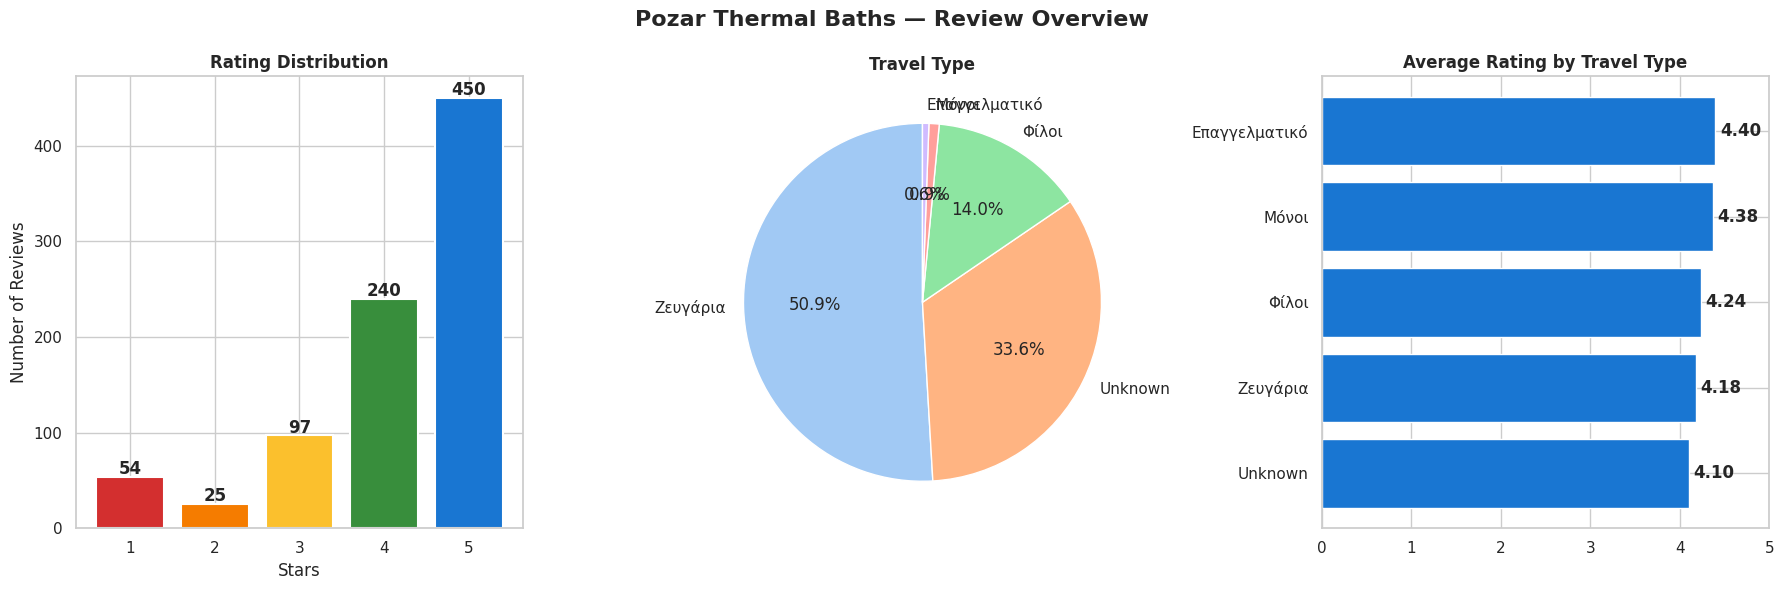

⭐ Average Rating: 4.16/5 | Total reviews: 866


In [5]:
# Color palette for ratings (1=red to 5=blue)
colors_rating = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Pozar Thermal Baths — Review Overview', fontsize=16, fontweight='bold')

# Chart 1: Rating distribution
rc = df['rating'].value_counts().sort_index()
bars = axes[0].bar(rc.index, rc.values, color=colors_rating, edgecolor='white', linewidth=1.5)
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, rc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(val), ha='center', fontweight='bold')

# Chart 2: Travel type breakdown
tc = df['travelType'].value_counts().head(6)
axes[1].pie(tc.values, labels=tc.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90)
axes[1].set_title('Travel Type', fontweight='bold')

# Chart 3: Average rating per travel type
avg = df.groupby('travelType')['rating'].mean().sort_values()
bars2 = axes[2].barh(avg.index, avg.values, color='#1976d2', edgecolor='white')
axes[2].set_title('Average Rating by Travel Type', fontweight='bold')
axes[2].set_xlim(0, 5)
for bar, val in zip(bars2, avg.values):
    axes[2].text(val+0.05, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'⭐ Average Rating: {df["rating"].mean():.2f}/5 | Total reviews: {len(df)}')

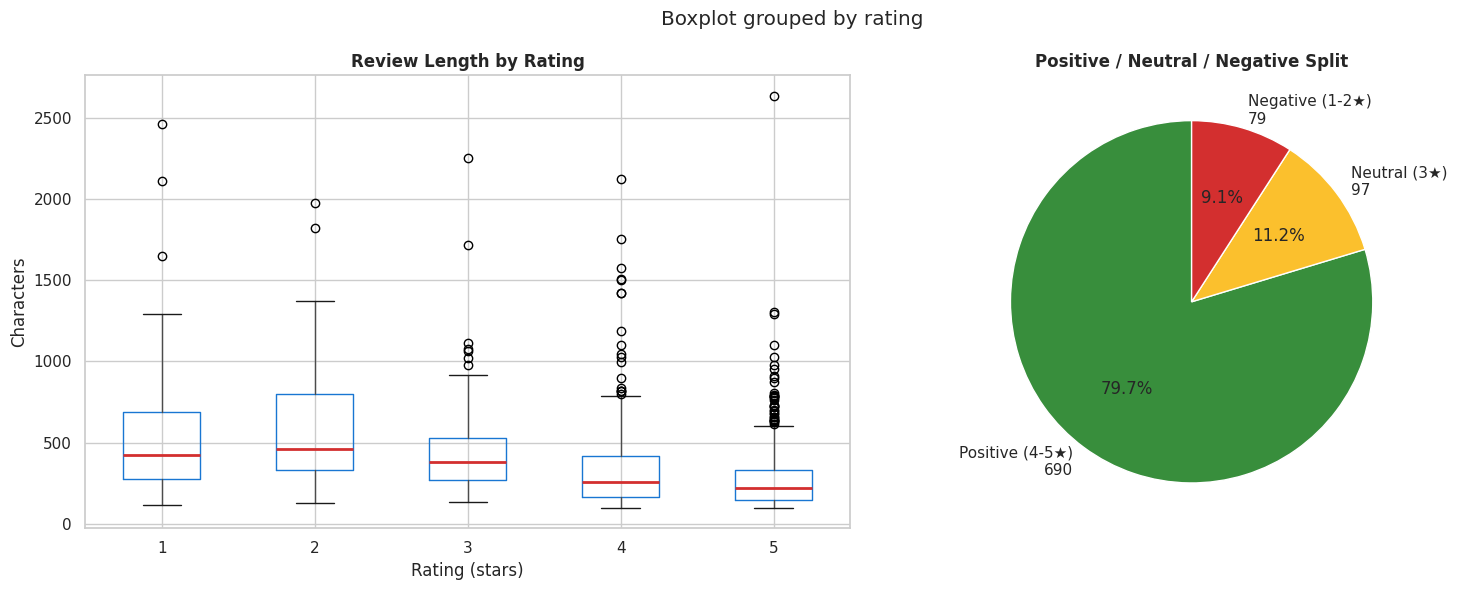

In [6]:
# Review length analysis and positive/negative split
df['text_length'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: review length by rating
# Longer negative reviews may indicate more detailed complaints
df.boxplot(column='text_length', by='rating', ax=axes[0],
           boxprops=dict(color='#1976d2'), medianprops=dict(color='#d32f2f', linewidth=2))
plt.sca(axes[0])
plt.title('Review Length by Rating', fontweight='bold')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Characters')

# Pie chart: positive / neutral / negative split based on rating
pos = (df['rating'] >= 4).sum()
neu = (df['rating'] == 3).sum()
neg = (df['rating'] <= 2).sum()
axes[1].pie([pos, neu, neg],
            labels=[f'Positive (4-5★)\n{pos}', f'Neutral (3★)\n{neu}', f'Negative (1-2★)\n{neg}'],
            colors=['#388e3c','#fbc02d','#d32f2f'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Positive / Neutral / Negative Split', fontweight='bold')

plt.tight_layout()
plt.savefig('rating_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 😊 Sentiment Analysis

**Model:** `nlptown/bert-base-multilingual-uncased-sentiment`

**Architecture:** BERT (Bidirectional Encoder Representations from Transformers)

**Why this model:**
- Supports 6 languages including Greek and English
- Fine-tuned on product/service reviews (similar domain to TripAdvisor)
- Returns a 1-5 star rating which we map to: Positive (4-5) / Neutral (3) / Negative (1-2)

> ⏳ This step takes **5-10 minutes** on Colab CPU. For faster results: Runtime → Change runtime type → T4 GPU

In [7]:
from transformers import pipeline
import torch

# Load the multilingual sentiment model
# This model was fine-tuned on 100k+ reviews in 6 languages
print('⏳ Loading sentiment model...')
sentiment_pipeline = pipeline(
    'text-classification',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    device=0 if torch.cuda.is_available() else -1  # Use GPU if available
)
print(f'✅ Model loaded! GPU available: {torch.cuda.is_available()}')

⏳ Loading sentiment model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Model loaded! GPU available: True


In [8]:
def get_sentiment(text):
    """
    Run sentiment analysis on a single review.
    - Truncates text to 512 characters (BERT token limit)
    - Maps 1-5 star output to Positive/Neutral/Negative
    """
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        stars = int(result['label'].split()[0])
        score = round(result['score'], 3)
        if stars >= 4:   sentiment = 'Positive'
        elif stars == 3: sentiment = 'Neutral'
        else:            sentiment = 'Negative'
        return sentiment, score
    except:
        return 'Unknown', 0.0

print('⏳ Running sentiment analysis on all reviews...')
results = df['text'].apply(get_sentiment)
df['sentiment'] = results.apply(lambda x: x[0])
df['sentiment_score'] = results.apply(lambda x: x[1])

print('✅ Sentiment analysis complete!')
print('\nSentiment distribution:')
print(df['sentiment'].value_counts())

⏳ Running sentiment analysis on all reviews...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Sentiment analysis complete!

Sentiment distribution:
sentiment
Positive    492
Negative    297
Neutral      77
Name: count, dtype: int64


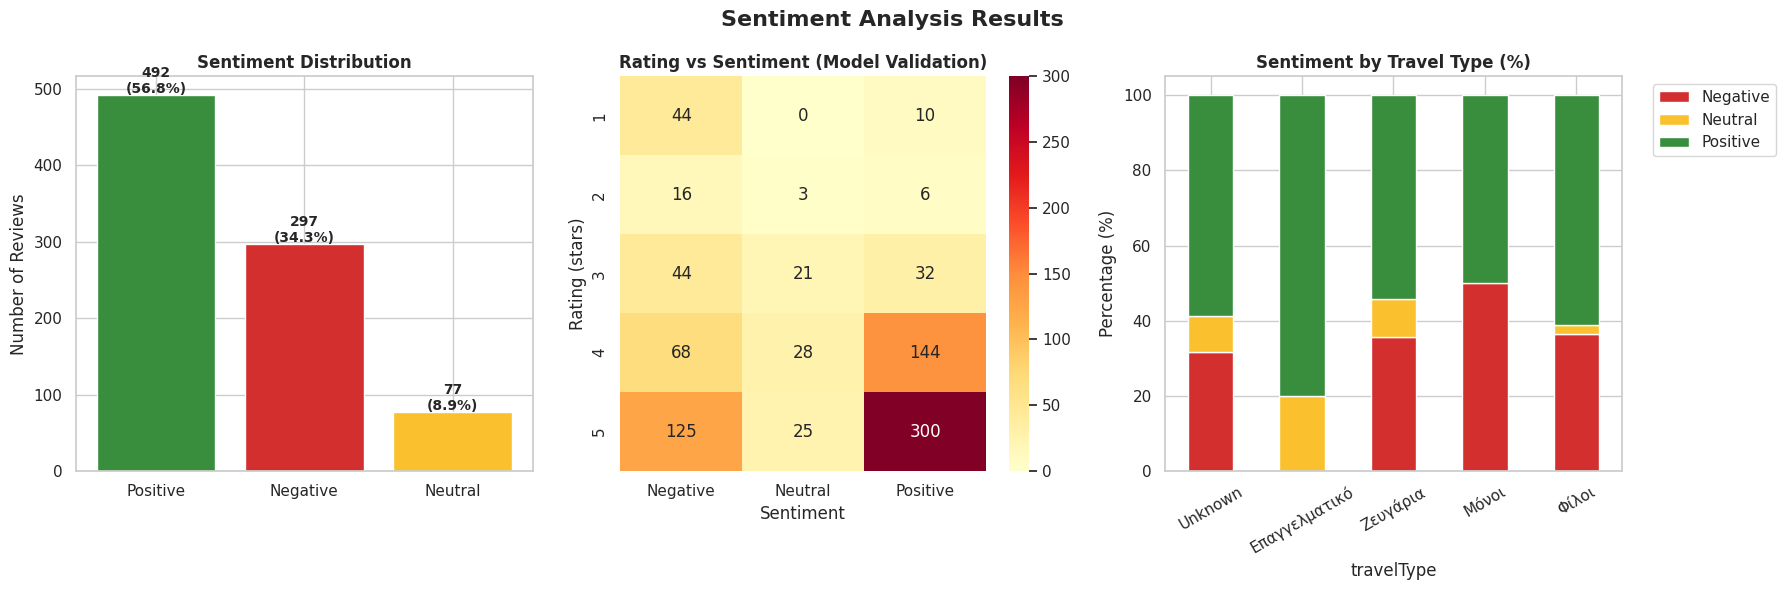

In [9]:
# Visualize sentiment analysis results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sentiment Analysis Results', fontsize=16, fontweight='bold')
sc = {'Positive':'#388e3c', 'Neutral':'#fbc02d', 'Negative':'#d32f2f', 'Unknown':'#9e9e9e'}

# Chart 1: Overall sentiment distribution
sent_counts = df['sentiment'].value_counts()
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[sc.get(s,'#9e9e9e') for s in sent_counts.index], edgecolor='white')
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# Chart 2: Heatmap of rating vs sentiment
# Shows alignment between star rating and model prediction
cross = pd.crosstab(df['rating'], df['sentiment'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Rating vs Sentiment (Model Validation)', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Rating (stars)')

# Chart 3: Sentiment breakdown by travel type
ts = df.groupby(['travelType','sentiment']).size().unstack(fill_value=0)
ts_pct = ts.div(ts.sum(axis=1), axis=0)*100
cols_order = [c for c in ['Negative','Neutral','Positive'] if c in ts_pct.columns]
ts_pct[cols_order].plot(kind='bar', ax=axes[2],
    color=[sc[c] for c in cols_order], edgecolor='white', stacked=True)
axes[2].set_title('Sentiment by Travel Type (%)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 🏷️ Topic Analysis

**Method:** Keyword-based topic detection

Each review is scanned for predefined keywords associated with 8 topics:
- Water/Pools, Cleanliness, Staff, Facilities, Prices, Nature/Scenery, Food/Café, Crowds/Waiting

A review can belong to multiple topics simultaneously.

In [10]:
# Define topics and their associated Greek keywords
TOPICS = {
    'Water / Pools':     ['νερό','πισίνα','πισίνες','ζεστό','θερμό','ιαματικό','καταρράκτης','καταρράκτες','πίεση','χλιαρό'],
    'Cleanliness':       ['καθαριότητα','καθαρό','καθαρά','βρώμικο','βρώμα','βρώμικα','άλατα','βρωμιά','υγιεινή'],
    'Staff':             ['προσωπικό','υπάλληλος','υπάλληλοι','αγένεια','αγενής','φιλικοί','εξυπηρέτηση','επαγγελματίες','ευγενικοί'],
    'Facilities':        ['αποδυτήρια','ντουλάπια','εγκαταστάσεις','ανακαίνιση','δωμάτιο','δωμάτια','υποδομή','ντουζ'],
    'Prices':            ['τιμή','τιμές','ακριβό','φθηνό','αξία','εισιτήριο','χρέωση','κόστος','λεφτά'],
    'Nature / Scenery':  ['φύση','τοπίο','δάσος','καστανιές','πράσινο','ομορφιά','μαγευτικό','μαγικό','βουνό'],
    'Food / Café':       ['φαγητό','εστιατόριο','καφέ','καφετέρια','ταβέρνα','βάφλα','καφές','σερβιτόρος'],
    'Crowds / Waiting':  ['κόσμος','πλήθος','αναμονή','ουρά','γεμάτο','ώρες','περίμενα','συνωστισμός']
}

def detect_topics(text):
    """Detect topics in a review by matching keywords."""
    text_lower = str(text).lower()
    found = [t for t, kws in TOPICS.items() if any(kw in text_lower for kw in kws)]
    return found if found else ['General Experience']

df['topics'] = df['text'].apply(detect_topics)
df['topics_str'] = df['topics'].apply(lambda x: ', '.join(x))

print('✅ Topic detection complete!')
df[['title','rating','topics_str']].head(5)

✅ Topic detection complete!


,title,rating,topics_str
0,Μαγικό,5,Staff
1,Λουτρά Ποζαρ,5,"Nature / Scenery, Food / Café"
2,Ήταν χάλια,1,"Water / Pools, Cleanliness, Staff, Facilities"
3,Φτιάξετε την πίεση του νερού στις prive πισίνες,1,"Water / Pools, Prices"
4,Αγενέστατο προσωπικό,1,"Water / Pools, Staff, Food / Café"


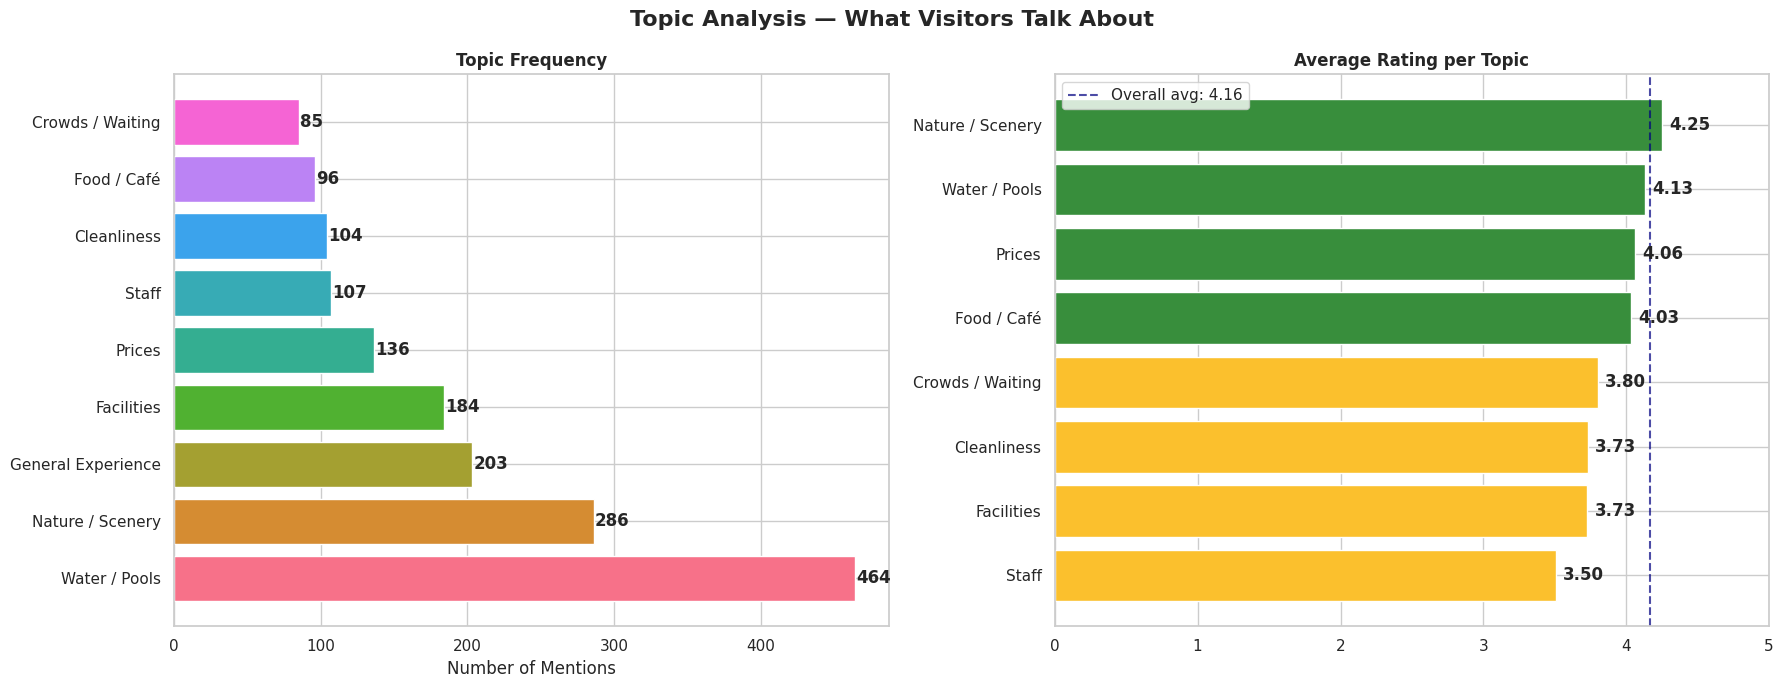

In [11]:
# Count topic mentions across all reviews
all_topics = [t for tl in df['topics'] for t in tl]
topic_counts = Counter(all_topics)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Topic Analysis — What Visitors Talk About', fontsize=16, fontweight='bold')

# Chart 1: Topic frequency
td = pd.DataFrame(topic_counts.most_common(), columns=['Topic','Mentions'])
pal = sns.color_palette('husl', len(td))
bars = axes[0].barh(td['Topic'], td['Mentions'], color=pal)
axes[0].set_title('Topic Frequency', fontweight='bold')
axes[0].set_xlabel('Number of Mentions')
for bar, val in zip(bars, td['Mentions']):
    axes[0].text(val+1, bar.get_y()+bar.get_height()/2, str(val), va='center', fontweight='bold')

# Chart 2: Average rating per topic
# Topics with lower average rating indicate areas needing improvement
tr = {t: df[df['topics'].apply(lambda x: t in x)]['rating'].mean() for t in TOPICS}
tr_df = pd.DataFrame(list(tr.items()), columns=['Topic','Avg Rating']).sort_values('Avg Rating')
bar_c = ['#d32f2f' if r<3 else '#fbc02d' if r<4 else '#388e3c' for r in tr_df['Avg Rating']]
bars2 = axes[1].barh(tr_df['Topic'], tr_df['Avg Rating'], color=bar_c, edgecolor='white')
axes[1].set_title('Average Rating per Topic', fontweight='bold')
axes[1].set_xlim(0, 5)
axes[1].axvline(df['rating'].mean(), color='navy', linestyle='--', alpha=0.7,
                label=f'Overall avg: {df["rating"].mean():.2f}')
axes[1].legend()
for bar, val in zip(bars2, tr_df['Avg Rating']):
    axes[1].text(val+0.05, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('topic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

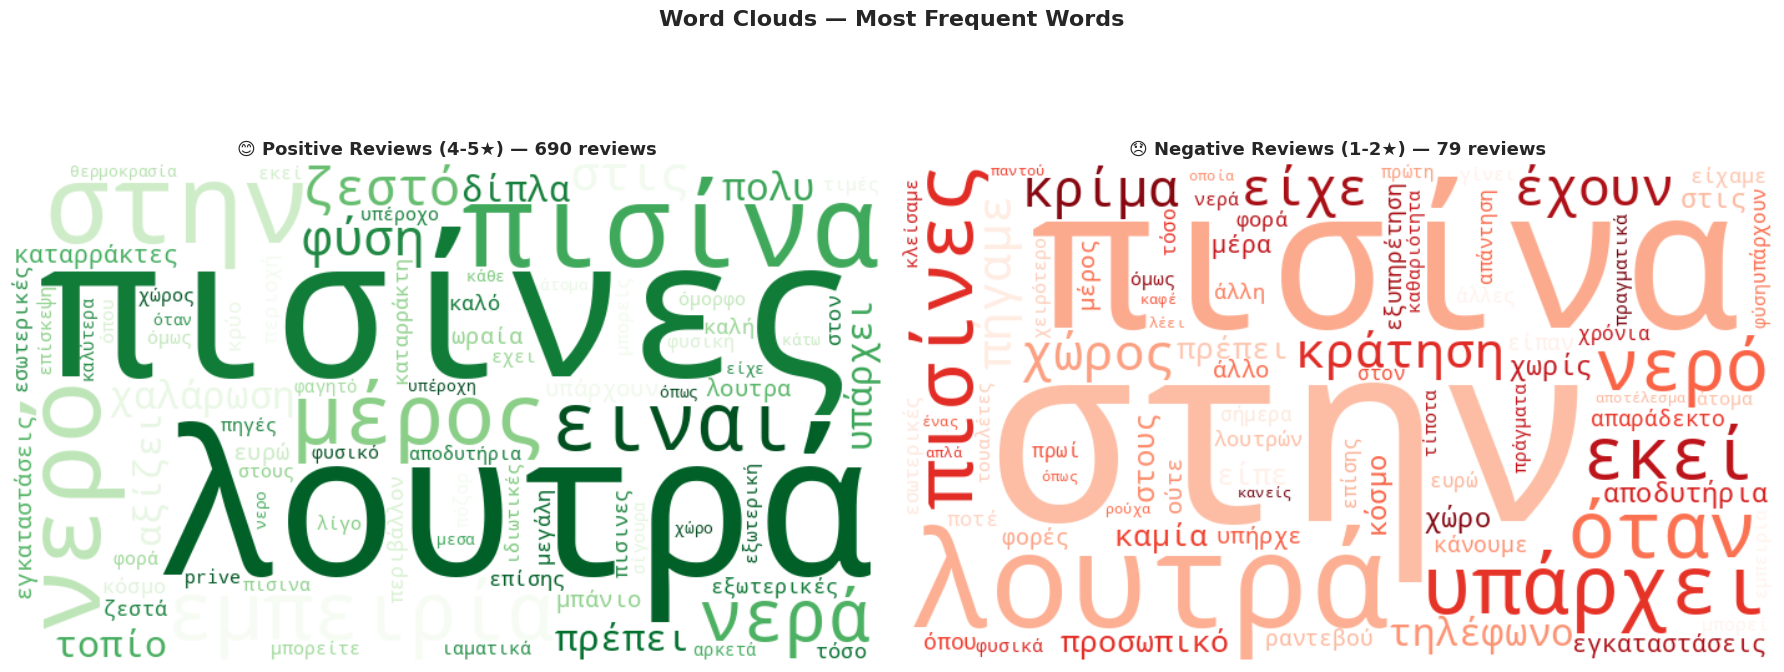

In [12]:
# Word Clouds: most frequent words in positive vs negative reviews
# Stopwords list to filter out common Greek function words
STOPWORDS_GR = {'και','να','το','τα','τον','την','της','τους','των','τις','ο','η','οι',
                'σε','για','με','από','που','ότι','αλλά','ή','αν','μας','σας','του',
                'ένα','είναι','ήταν','έχει','δεν','δε','θα','πολύ','έτσι','μόνο',
                'αυτό','αυτά','αυτή','εδώ','ακόμα','μέχρι','πριν','μετά','γιατί',
                'κάνει','κάνουν','μια','κάτι','όλα','όλοι','όλες','πώς','μέσα'}

def make_wordcloud(texts, title, cmap, ax):
    """Generate a word cloud from a list of texts."""
    words = re.findall(r'\b[α-ωάέήίόύώΑ-ΩΆΈΉΊΌΎΏa-zA-Z]{4,}\b', ' '.join(texts).lower())
    words = [w for w in words if w not in STOPWORDS_GR]
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(' '.join(words))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Word Clouds — Most Frequent Words', fontsize=16, fontweight='bold')

pos_texts = df[df['rating'] >= 4]['text'].tolist()
neg_texts = df[df['rating'] <= 2]['text'].tolist()

make_wordcloud(pos_texts, f'😊 Positive Reviews (4-5★) — {len(pos_texts)} reviews', 'Greens', axes[0])
make_wordcloud(neg_texts, f'😞 Negative Reviews (1-2★) — {len(neg_texts)} reviews', 'Reds', axes[1])

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 📈 Combined Charts
Cross-analysis of sentiment and topics to identify which areas drive positive or negative experiences.

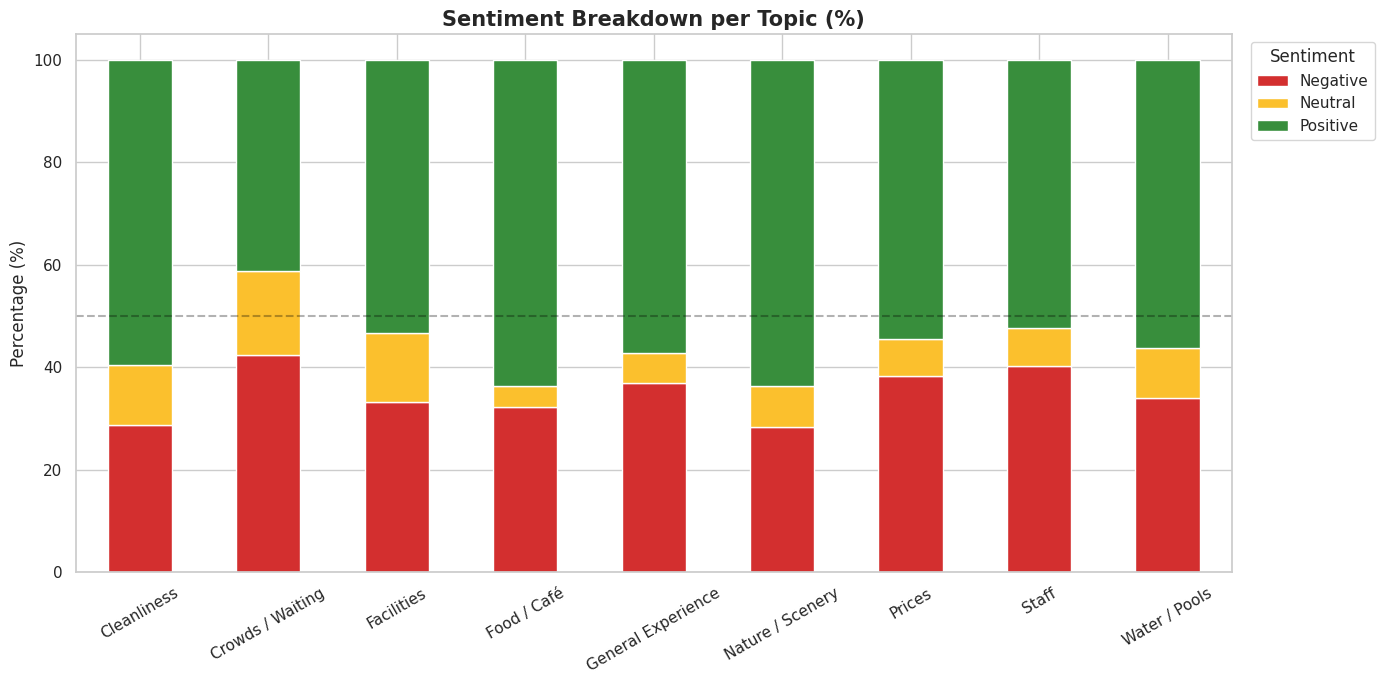

In [13]:
# Stacked bar: sentiment breakdown per topic
# This chart shows which topics are associated with positive vs negative reviews
rows = [{'topic':t,'sentiment':row['sentiment'],'rating':row['rating']}
        for _,row in df.iterrows() for t in row['topics']]
tsd = pd.DataFrame(rows)
pivot = pd.crosstab(tsd['topic'], tsd['sentiment'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)*100

fig, ax = plt.subplots(figsize=(14, 7))
sc = {'Positive':'#388e3c','Neutral':'#fbc02d','Negative':'#d32f2f'}
cols_order = [c for c in ['Negative','Neutral','Positive'] if c in pivot_pct.columns]
pivot_pct[cols_order].plot(kind='bar', ax=ax, stacked=True,
    color=[sc[c] for c in cols_order], edgecolor='white')
ax.set_title('Sentiment Breakdown per Topic (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01,1))
ax.tick_params(axis='x', rotation=30)
ax.axhline(50, color='black', linestyle='--', alpha=0.3, label='50% line')
plt.tight_layout()
plt.savefig('sentiment_per_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 💾 Save Results

In [14]:
# Save the enriched dataset with sentiment and topic columns
output = df[['title','rating','travelType','text','sentiment','sentiment_score','topics_str']]
output.to_excel('Pozar_Reviews_With_Sentiment.xlsx', index=False)

# Download the file
from google.colab import files
files.download('Pozar_Reviews_With_Sentiment.xlsx')

# Print final summary
print('✅ File saved: Pozar_Reviews_With_Sentiment.xlsx')
print(f'\n📊 ANALYSIS SUMMARY')
print(f'{'='*40}')
print(f'Total reviews    : {len(df)}')
print(f'Average rating   : {df["rating"].mean():.2f}/5')
print(f'Positive         : {(df["sentiment"]=="Positive").sum()} ({(df["sentiment"]=="Positive").mean()*100:.1f}%)')
print(f'Neutral          : {(df["sentiment"]=="Neutral").sum()} ({(df["sentiment"]=="Neutral").mean()*100:.1f}%)')
print(f'Negative         : {(df["sentiment"]=="Negative").sum()} ({(df["sentiment"]=="Negative").mean()*100:.1f}%)')
print(f'\n🏷️  Most mentioned topics:')
for topic, count in topic_counts.most_common(5):
    print(f'   {topic}: {count} mentions')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File saved: Pozar_Reviews_With_Sentiment.xlsx

📊 ANALYSIS SUMMARY
Total reviews    : 866
Average rating   : 4.16/5
Positive         : 492 (56.8%)
Neutral          : 77 (8.9%)
Negative         : 297 (34.3%)

🏷️  Most mentioned topics:
   Water / Pools: 464 mentions
   Nature / Scenery: 286 mentions
   General Experience: 203 mentions
   Facilities: 184 mentions
   Prices: 136 mentions
